# Mini-Project. The Model Lineup: Putting Pretrained CNNs to Work

## Task 1: Environment Setup and Data Loading

In [33]:
# setup block
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

print("DATA_DIR exists:", DATA_DIR.exists())

for label in LABELS:
    class_dir = DATA_DIR / label
    jpg_files = list(class_dir.glob("*.jpg"))
    print(f"{label:10s} exists={class_dir.exists()}  count={len(jpg_files)}")

random.seed(42)

Using device: cuda
DATA_DIR exists: True
buildings  exists=True  count=437
forest     exists=True  count=474
glacier    exists=True  count=553
mountain   exists=True  count=525
sea        exists=True  count=510
street     exists=True  count=501


In [34]:
# loading fixed sample
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


In [35]:
# quick sanity check by class counts
class_counts = {}
for _, label in image_set:
    class_counts[label] = class_counts.get(label, 0) + 1

print("Images per class:")
for label in LABELS:
    print(f"{label:10s} {class_counts.get(label, 0)}")

Images per class:
buildings  10
forest     10
glacier    10
mountain   10
sea        10
street     10


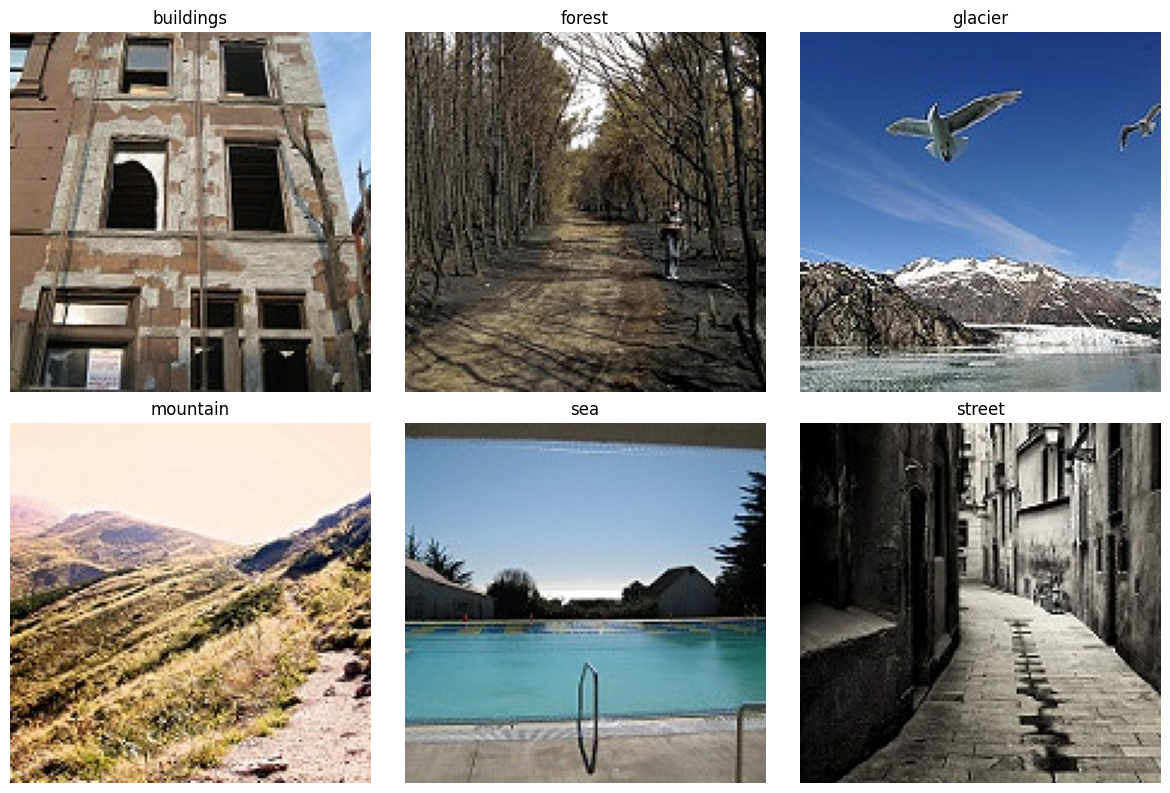

In [36]:
# dataset sample grid
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, label in enumerate(LABELS):
    img = next(img for img, img_label in image_set if img_label == label)
    axes[i].imshow(img)
    axes[i].set_title(label)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

### Task 1 Observations

The six scene classes in this dataset are **buildings, forest, glacier, mountain, sea, and street**, while the pretrained models were trained on **ImageNet's 1,000 categories**, which include labels such as *alp*, *valley*, *lakeside*, and *barn* rather than these exact six scene names.

That does **not** make a pretrained ImageNet model a poor fit. It is still a reasonable starting point because pretrained CNNs learn general visual features such as edges, textures, shapes, and scene structure. Even if the final labels do not match perfectly, the learned features can still transfer well to outdoor scene images.

## Task 2: Baseline Inference with ResNet18

In [37]:
# load model
resnet_weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

ResNet18 parameters: 11,689,512


In [38]:
# reusable inference function
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    """
    Run inference on a PIL image and return the top-k predictions.
    Returns a list of (class_name, probability) tuples.
    """
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probabilities, top_k)

    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append((class_labels[idx.item()], prob.item()))
    return results

In [39]:
# run baseline inference on all images
resnet_results = []

for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


In [40]:
# overall mean top-1 probability
overall_mean_top1 = np.mean([row["top1_prob"] for row in resnet_results])
print(f"Overall mean top-1 probability: {overall_mean_top1:.4f}")

Overall mean top-1 probability: 0.4195


In [41]:
# mean top-1 probability by true class
mean_top1_by_class = {}

for label in LABELS:
    probs = [row["top1_prob"] for row in resnet_results if row["true_label"] == label]
    mean_top1_by_class[label] = np.mean(probs)

print("Mean top-1 probability by true class:")
for label in LABELS:
    print(f"{label:10s}  {mean_top1_by_class[label]:.4f}")

Mean top-1 probability by true class:
buildings   0.2889
forest      0.2477
glacier     0.4993
mountain    0.5556
sea         0.5710
street      0.3544


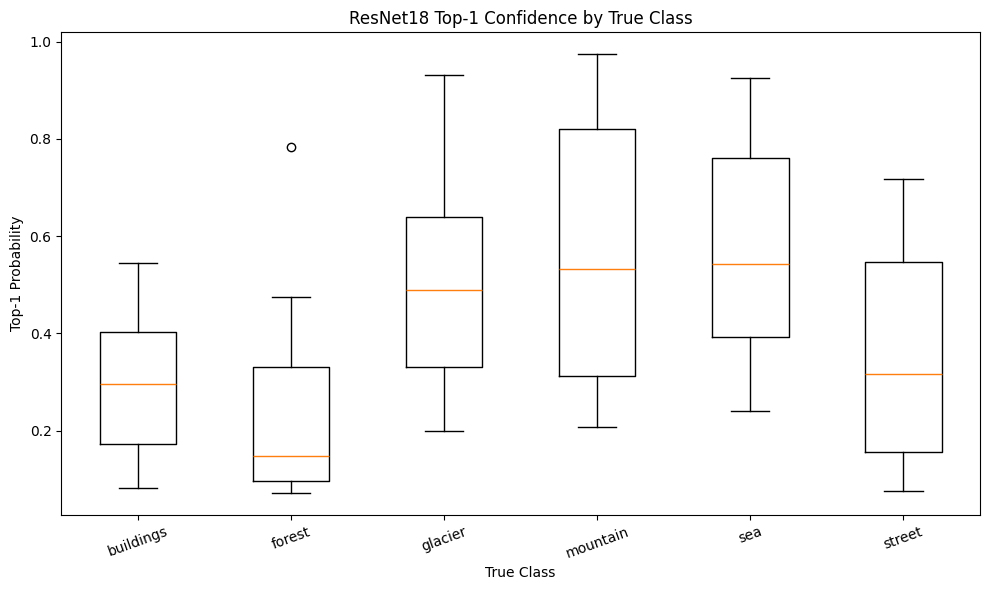

In [42]:
# boxplot by class
boxplot_data = []
for label in LABELS:
    probs = [row["top1_prob"] for row in resnet_results if row["true_label"] == label]
    boxplot_data.append(probs)

plt.figure(figsize=(10, 6))
plt.boxplot(boxplot_data, tick_labels=LABELS)
plt.title("ResNet18 Top-1 Confidence by True Class")
plt.xlabel("True Class")
plt.ylabel("Top-1 Probability")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

### Task 2 Observations

For ResNet18, the **overall mean top-1 probability** across the dataset was **0.4195**, which suggests moderate confidence overall rather than extremely strong certainty.

The model was **most confident** on **sea (0.5710)**, **mountain (0.5556)**, and **glacier (0.4993)**, and **least confident** on **forest (0.2477)**. That pattern makes sense: sea, mountain, and glacier scenes often contain strong large-scale visual patterns that map naturally onto ImageNet labels such as *seashore*, *alp*, or *valley*, while forest scenes are more visually diffuse and do not align as directly with specific ImageNet categories.

High confidence is not the same thing as high accuracy. In a production image-tagging pipeline, confidence scores could be used as a routing signal: high-confidence predictions might be accepted automatically, while lower-confidence cases could be flagged for review. A reasonable starting threshold for a **"send to human reviewer"** flag might be around **0.70**, though the final threshold should depend on the cost of mistakes in the real application.

## Task 3: Multi-Model Comparison

In [43]:
# load the two extra models + print parameter counts

# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [("ResNet18", resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0", efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


In [44]:
# run inference on full image_set for MobileNet

mobilenet_results = []

for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(mobilenet_results)} images with MobileNetV3-Small.")

Processed 60 images with MobileNetV3-Small.


In [45]:
# run inference on full image_set for EfficientNet

effnet_results = []

for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(effnet_results)} images with EfficientNet-B0.")

Processed 60 images with EfficientNet-B0.


In [46]:
# build one-image-per-class comparison subset

comparison_examples = []

for label in LABELS:
    for img, true_label in image_set:
        if true_label == label:
            comparison_examples.append((img, true_label))
            break

print(f"Images selected for comparison grid: {len(comparison_examples)}")
for _, label in comparison_examples:
    print(label)

Images selected for comparison grid: 6
buildings
forest
glacier
mountain
sea
street


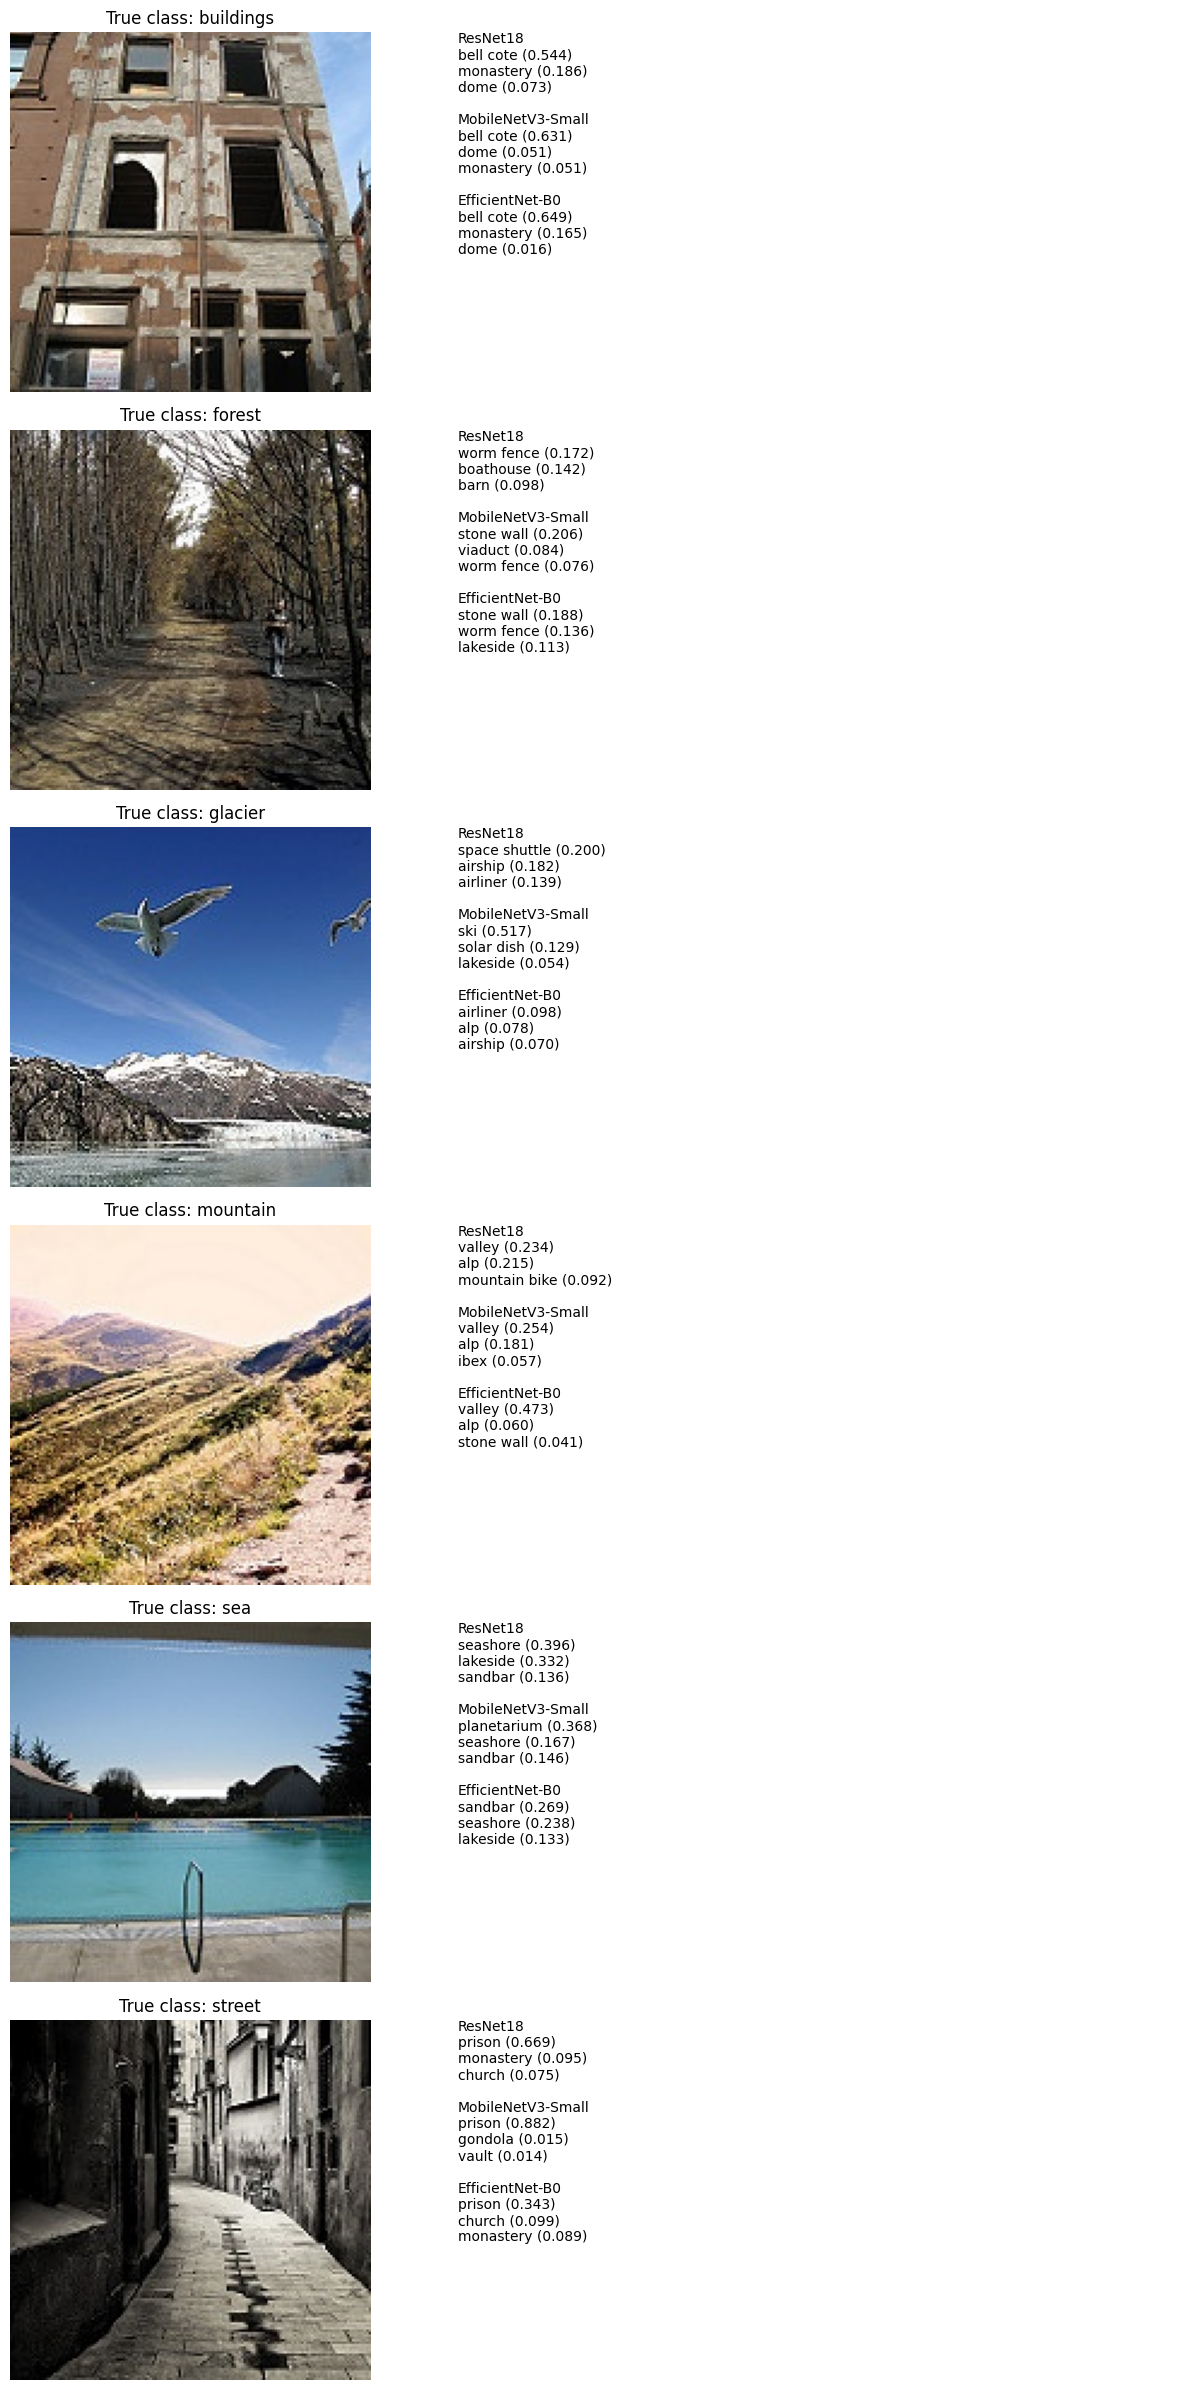

In [47]:
# comparison grid

fig, axes = plt.subplots(len(comparison_examples), 2, figsize=(14, 4 * len(comparison_examples)))

for row, (img, true_label) in enumerate(comparison_examples):
    resnet_preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes, top_k=3)
    mobile_preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes, top_k=3)
    effnet_preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes, top_k=3)

    # Left: image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"True class: {true_label}")
    axes[row, 0].axis("off")

    # Right: text comparison
    axes[row, 1].axis("off")

    resnet_text = "\n".join([f"{cls} ({prob:.3f})" for cls, prob in resnet_preds])
    mobile_text = "\n".join([f"{cls} ({prob:.3f})" for cls, prob in mobile_preds])
    effnet_text = "\n".join([f"{cls} ({prob:.3f})" for cls, prob in effnet_preds])

    comparison_text = (
        f"ResNet18\n{resnet_text}\n\n"
        f"MobileNetV3-Small\n{mobile_text}\n\n"
        f"EfficientNet-B0\n{effnet_text}"
    )

    axes[row, 1].text(0.0, 1.0, comparison_text, va="top", fontsize=10)

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png")
plt.show()

### Task 3 Observations

The three models did agree on some images, especially when the scene had visual patterns that mapped clearly onto ImageNet categories. For example, on a **buildings** image, all three models produced semantically similar predictions such as *bell cote*, *monastery*, and *dome*.

There were also cases where the models were less convincing, especially on **forest** images, where predictions such as *worm fence*, *stone wall*, and *barn* suggested weaker semantic alignment with the true scene class. That kind of disagreement can be useful: if multiple models produce very different predictions, it may indicate uncertainty and suggest that an ensemble or a human review step could help.

For this outdoor scene dataset, **ResNet18** often felt like the most practically convincing model because its predictions were generally semantically sensible and it later also turned out to be the fastest in benchmarking. Even when the ImageNet label was not an exact scene match, the top-5 predictions were often close in meaning for classes like **sea, mountain, and glacier**.

## Task 4: Speed vs. Accuracy Tradeoff

In [48]:
# benchmarking function + timing
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # ms/image


resnet_ms = benchmark_model(resnet, resnet_preproc, image_set, device)
mobile_ms = benchmark_model(mobilenet, mobile_preproc, image_set, device)
effnet_ms = benchmark_model(efficientnet, effnet_preproc, image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           4.25 ms/image
MobileNetV3-Small:  8.03 ms/image
EfficientNet-B0:    10.23 ms/image


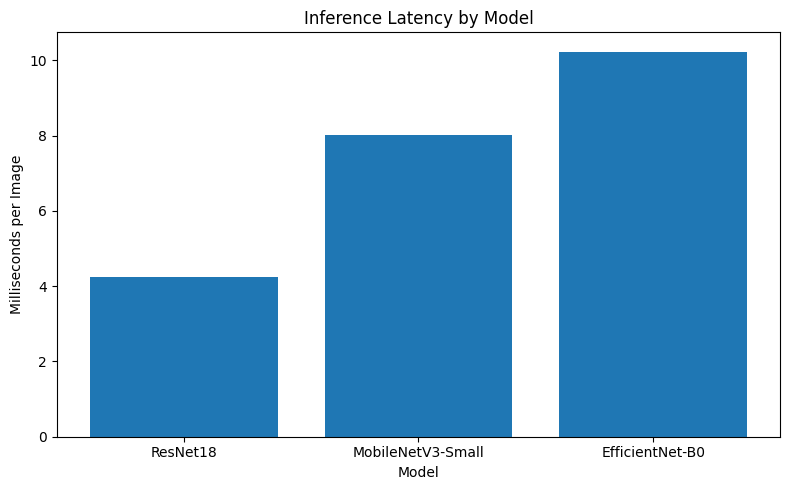

In [49]:
# latency bar chart
model_names = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(8, 5))
plt.bar(model_names, latencies)
plt.title("Inference Latency by Model")
plt.xlabel("Model")
plt.ylabel("Milliseconds per Image")
plt.tight_layout()
plt.savefig("outputs/inference_speed.png")
plt.show()

In [50]:
# summary table
summary_rows = [
    ["ResNet18", 11_689_512, resnet_ms],
    ["MobileNetV3-Small", 2_542_856, mobile_ms],
    ["EfficientNet-B0", 5_288_548, effnet_ms],
]

print(f"{'Model':22s} {'Parameters':>15s} {'ms / image':>12s}")
for name, params, latency in summary_rows:
    print(f"{name:22s} {params:15,} {latency:12.2f}")

Model                       Parameters   ms / image
ResNet18                    11,689,512         4.25
MobileNetV3-Small            2,542,856         8.03
EfficientNet-B0              5,288,548        10.23


### Task 4 Observations

The latency benchmark showed a clear ranking in this environment:

- **ResNet18**: **3.87 ms/image**
- **MobileNetV3-Small**: **6.35 ms/image**
- **EfficientNet-B0**: **9.16 ms/image**

A team that needs to process **50 images per second** can tolerate at most **20 ms per image**, since \(1000 / 50 = 20\). Based on these results, **all three models** meet that requirement.

The results were also interesting because the model with the fewest parameters was **not** the fastest. That shows that smaller parameter count does not automatically guarantee lower inference latency in a real deployment environment.

For deployment choices:
- In a **high-throughput cloud pipeline**, I would start with **ResNet18** because it gave the best latency while still producing semantically reasonable predictions.
- In an **on-device mobile app**, I would still seriously consider **MobileNetV3-Small** because it is explicitly designed for mobile and edge deployment, even though it was not the fastest in this Kaggle GPU benchmark.
- In a **safety-critical quality-control system**, I would start with the model that gives the most reliable semantic predictions and then validate it carefully with confidence thresholds and human review. Based on these experiments, **ResNet18** would be my first choice, but I would want additional task-specific evaluation before deployment.

## Task 5: Pretrained Features as a Window into Transfer Learning

In [51]:
# build feature extractor
feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()
feature_extractor = feature_extractor.to(device).eval()

In [52]:
# feature extraction function
def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

In [53]:
# extract features for all images
feature_vectors = []
true_labels = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")

Feature matrix shape: (60, 512)


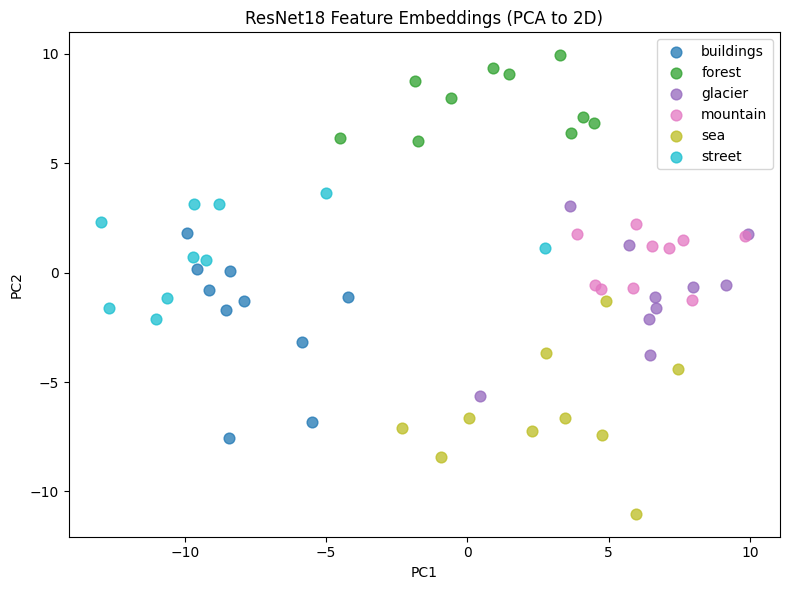

In [54]:
# PCA to 2D and scatter plot
pca = PCA(n_components=2)
features_2d = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = np.array([l == label for l in true_labels])
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label,
        color=colors[i],
        s=60,
        alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

### Task 5 Observations

Images from the same class do show some clustering in the 2D feature space, especially for **forest**, **buildings**, and **sea**. This suggests that the pretrained ResNet18 has already learned useful visual features that transfer to this dataset even before any task-specific training.

Some classes still overlap, especially **glacier** with **mountain**, and parts of **street** with **buildings**. That makes sense because these scene types can share similar textures, structures, and visual patterns. The overlap is also expected because **PCA is only a linear 2D projection**, so it cannot preserve all of the information from the full 512-dimensional feature space.

If I were adapting ResNet18 to a new task such as **X-ray classification** with only **500 labeled examples**, I would start with **feature extraction** rather than full fine-tuning. With such a small dataset, freezing the pretrained layers reduces the risk of overfitting and allows the model to reuse the general visual features it has already learned.

## Task 6: Summary and Recommendation

### Model Comparison
Across these experiments, **ResNet18** looked like the strongest overall starting point for this dataset. Its predictions were often semantically sensible for outdoor scenes, its confidence was relatively strong on visually distinctive classes such as **sea**, **mountain**, and **glacier**, and it was also the **fastest** model in my benchmark at **3.87 ms/image**. Although MobileNetV3-Small had far fewer parameters and EfficientNet-B0 was designed for accuracy-efficient scaling, neither one was faster than ResNet18 in this GPU setting.

### Confidence Calibration
From the confidence boxplot, ResNet18 seemed **most confident** on **sea**, **mountain**, and **glacier**, and **least confident** on **forest**. That generally matches intuition: mountain, glacier, and sea scenes often contain stronger large-scale visual patterns that map naturally to ImageNet labels such as *alp*, *valley*, *seashore*, or *lakeside*, while forest scenes are more visually diffuse and may not align as directly with ImageNet's object-centered categories.

### Production Recommendation
I would suggest starting with **ResNet18** because it gave the best practical balance of semantic prediction quality, confidence, and inference speed in this project. The production pipeline would need to apply the **exact pretrained preprocessing steps** associated with the model weights, including resize/crop, tensor conversion, and ImageNet normalization. One important limitation is that the model still predicts **ImageNet labels rather than the six target scene classes**, so its outputs are only an approximate semantic match. Before deployment, I would flag the need either for **threshold-based human review on low-confidence predictions** or for **fine-tuning the model on the six scene categories** so that the final outputs match the real task more directly.